В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [ ]:
!pip install opendatasets --upgrade --quiet

In [ ]:
import opendatasets as od
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
import joblib

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = ('/content/drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5')

print(os.listdir(data_dir))

['sample_submission.csv', 'test.csv', 'train.csv', 'log_reg.joblib', 'val_targets.parquet', 'val_inputs.parquet', 'train_inputs.parquet', 'train_targets.parquet', 'submission_poly4.csv', 'submission.csv']


In [ ]:
train_path = os.path.join(data_dir, 'train.csv')
test_path = os.path.join(data_dir, 'test.csv')
submission_path = os.path.join(data_dir, 'sample_submission.csv')

raw_df = pd.read_csv(train_path)
test_raw_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(submission_path)

print('Train shape:', raw_df.shape)
print('Test shape:', test_raw_df.shape)
print('Submission shape:', sample_submission.shape)

display(raw_df.head())

Train shape: (15000, 14)
Test shape: (10000, 13)
Submission shape: (10000, 2)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [ ]:
train_df, val_df = train_test_split(raw_df, test_size=0.25, random_state=42, stratify=raw_df['Exited'])

print('Train shape:', train_df.shape)
print('Validation shape:', val_df.shape)

Train shape: (11250, 14)
Validation shape: (3750, 14)


In [ ]:
print(raw_df['Exited'].value_counts(normalize=True))

print('\nTrain:')
print(train_df['Exited'].value_counts(normalize=True))

print('\nValidation:')
print(val_df['Exited'].value_counts(normalize=True))

Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

Train:
Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

Validation:
Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [ ]:
target_col = 'Exited'

In [ ]:
input_cols = [
    column for column in train_df.columns
    if column != target_col
]

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [ ]:
print('Input columns:')
print(input_cols)

print('\nTrain inputs shape:', train_inputs.shape)
print('Train targets shape:', train_targets.shape)

print('\nValidation inputs shape:', val_inputs.shape)
print('Validation targets shape:', val_targets.shape)

Input columns:
['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Train inputs shape: (11250, 13)
Train targets shape: (11250,)

Validation inputs shape: (3750, 13)
Validation targets shape: (3750,)


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [ ]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

In [ ]:
print('Numeric columns:')
print(numeric_cols)

print('\nCategorical columns:')
print(categorical_cols)

Numeric columns:
['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Categorical columns:
['Surname', 'Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти передобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значень з `train_inputs`, `val_inputs` використовуючи `display()`.

In [ ]:
missing_values = pd.DataFrame({
    'train_missing': train_inputs.isna().sum(),
    'train_missing_%': train_inputs.isna().mean() * 100,
    'val_missing': val_inputs.isna().sum(),
    'val_missing_%': val_inputs.isna().mean() * 100
})

display(missing_values)

,train_missing,train_missing_%,val_missing,val_missing_%
id,0,0.0,0,0.0
CustomerId,0,0.0,0,0.0
Surname,0,0.0,0,0.0
CreditScore,0,0.0,0,0.0
Geography,0,0.0,0,0.0
Gender,0,0.0,0,0.0
Age,0,0.0,0,0.0
Tenure,0,0.0,0,0.0
Balance,0,0.0,0,0.0
NumOfProducts,0,0.0,0,0.0


У наборі даних пропущені значення відсутні, тому заповнення пропусків не проводиться.

In [ ]:
print('Повністю однакових рядків:')
print(train_df.duplicated().sum())

Повністю однакових рядків:
0


In [ ]:
print('Кількість унікальних CustomerId:')
print(train_df['CustomerId'].nunique())

Кількість унікальних CustomerId:
5511


In [ ]:
print('Кількість рядків:')
print(len(train_df))

Кількість рядків:
11250


In [ ]:
print('Найчастіші CustomerId:')
display(train_df['CustomerId'].value_counts().head(10))

Найчастіші CustomerId:


,count
CustomerId,
15686963.0,15
15682355.0,14
15692406.0,14
15758813.0,12
15662494.0,12
15806945.0,12
15682533.0,11
15572390.0,11
15703394.0,11


In [ ]:
duplicated_customers = train_df[train_df['CustomerId'].duplicated(keep=False)].sort_values('CustomerId')
display(duplicated_customers.head(10))

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
12848,12848,15566689.0,T'ien,579.0,France,Male,36.0,7.0,143390.51,1.0,1.0,0.0,119817.19,0.0
8042,8042,15566689.0,Milanesi,521.0,France,Male,36.0,3.0,0.00,2.0,1.0,0.0,51380.90,0.0
9915,9915,15566689.0,Yudina,627.0,France,Male,31.0,2.0,0.00,2.0,1.0,0.0,62733.05,0.0
8014,8014,15567442.0,Hsia,683.0,Germany,Female,35.0,1.0,81828.22,2.0,1.0,1.0,26578.69,0.0
11519,11519,15567442.0,Trevisano,521.0,Germany,Male,36.0,5.0,116363.37,1.0,1.0,0.0,67734.79,0.0
8093,8093,15567442.0,Hsing,692.0,France,Male,36.0,7.0,0.00,1.0,1.0,0.0,50368.63,0.0
2451,2451,15567993.0,Baresi,553.0,France,Male,37.0,10.0,0.00,2.0,1.0,1.0,188484.52,0.0
5996,5996,15567993.0,T'ang,581.0,France,Male,29.0,2.0,114940.67,1.0,1.0,1.0,96660.76,0.0
5293,5293,15568326.0,Pisani,637.0,France,Male,37.0,6.0,0.00,1.0,0.0,0.0,132973.17,0.0
2875,2875,15568326.0,Ch'ang,667.0,Germany,Male,45.0,10.0,79962.55,2.0,1.0,0.0,173837.54,0.0


Повністю однакових рядків у даних немає. Значення `CustomerId` повторюються, але рядки з однаковим `CustomerId` мають різні характеристики, тому ці рядки не видаляються.

Колонки `id` і `CustomerId` є технічними ідентифікаторами, а `Surname` має велику кількість унікальних текстових значень. Тому ці три колонки не використовуватимуться для навчання базової моделі

In [ ]:
cols_to_drop = ['id', 'CustomerId', 'Surname']

train_inputs = train_inputs.drop(
    columns=cols_to_drop,
    errors='ignore'
).copy()

val_inputs = val_inputs.drop(
    columns=cols_to_drop,
    errors='ignore'
).copy()

In [ ]:
numeric_cols = train_inputs.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = train_inputs.select_dtypes(
    include='object'
).columns.tolist()

In [ ]:
print('Numeric columns:')
print(numeric_cols)

print('\nCategorical columns:')
print(categorical_cols)

Numeric columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Categorical columns:
['Geography', 'Gender']


In [ ]:
scaler = MinMaxScaler()

scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoder.fit(train_inputs[categorical_cols])

encoded_cols = encoder.get_feature_names_out(
    categorical_cols
).tolist()

train_inputs[encoded_cols] = encoder.transform(
    train_inputs[categorical_cols]
)

val_inputs[encoded_cols] = encoder.transform(
    val_inputs[categorical_cols]
)

In [ ]:
train_inputs = train_inputs.drop(
    columns=categorical_cols
)

val_inputs = val_inputs.drop(
    columns=categorical_cols
)

In [ ]:
print('Train shape:', train_inputs.shape)
print('Validation shape:', val_inputs.shape)

print('\nТипи колонок у train:')
print(train_inputs.dtypes)

Train shape: (11250, 13)
Validation shape: (3750, 13)

Типи колонок у train:
CreditScore          float64
Age                  float64
Tenure               float64
Balance              float64
NumOfProducts        float64
HasCrCard            float64
IsActiveMember       float64
EstimatedSalary      float64
Geography_France     float64
Geography_Germany    float64
Geography_Spain      float64
Gender_Female        float64
Gender_Male          float64
dtype: object


In [ ]:
display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,0.632458,0.259259,0.5,0.622726,0.000000,1.0,1.0,0.433916,1.0,0.0,0.0,0.0,1.0
14199,0.479714,0.259259,0.4,0.571232,0.000000,1.0,0.0,0.888712,0.0,1.0,0.0,1.0,0.0
1856,0.591885,0.074074,0.4,0.000000,0.333333,1.0,1.0,0.813017,1.0,0.0,0.0,1.0,0.0
3013,0.653938,0.555556,0.3,0.000000,0.333333,1.0,0.0,0.599071,1.0,0.0,0.0,0.0,1.0
8266,0.632458,0.314815,0.7,0.000000,0.333333,1.0,0.0,0.502109,1.0,0.0,0.0,1.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1855,0.267303,0.203704,0.9,0.570579,0.0,0.0,0.0,0.279047,1.0,0.0,0.0,0.0,1.0
1273,0.398568,0.425926,0.3,0.590481,0.0,1.0,0.0,0.884371,0.0,1.0,0.0,0.0,1.0
5414,0.453461,0.240741,0.7,0.000000,0.0,1.0,1.0,0.751226,1.0,0.0,0.0,0.0,1.0
10923,0.396181,0.703704,0.3,0.000000,1.0,1.0,0.0,0.514675,1.0,0.0,0.0,0.0,1.0
5835,0.758950,0.444444,0.5,0.000000,0.0,1.0,1.0,0.909003,0.0,0.0,1.0,1.0,0.0


### Передобробка даних

1. Перевірила дані на пропущені значення. Пропусків не знайдено, тому заповнення не виконувалось.

2. Перевірила дублікати. Повних дублікатів не виявлено. Повторювані CustomerId відповідають різним записам клієнтів, тому не видалялись.

3. Видалили колонки id, CustomerId та Surname, оскільки вони є ідентифікаторами або містять текстову інформацію, яка не є корисною для базової логістичної регресії.

4. Масштабували числові ознаки за допомогою MinMaxScaler, щоб усі числові змінні були в одному діапазоні.

5. Закодували категоріальні ознаки (Geography, Gender) методом One-Hot Encoding, щоб модель могла працювати з ними.

6. Видалили початкові категоріальні колонки після кодування.

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [ ]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (11250, 13)
train_targets: (11250,)
val_inputs: (3750, 13)
val_targets: (3750,)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_inputs.to_parquet('drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/train_inputs.parquet')
val_inputs.to_parquet('drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/val_targets.parquet')

In [ ]:
!ls 'drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5'

log_reg.joblib	       test.csv		      val_inputs.parquet
sample_submission.csv  train.csv	      val_targets.parquet
submission.csv	       train_inputs.parquet
submission_poly4.csv   train_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [ ]:
X_train = train_inputs
X_val = val_inputs

y_train = train_targets
y_val = val_targets

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

C_values = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20]

for C in C_values:
    model = LogisticRegression(
        C=C,
        random_state=42,
        max_iter=1000
    )

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, probs)

    print(f"C={C:<5} AUROC={auc:.5f}")

C=0.01  AUROC=0.84702
C=0.05  AUROC=0.87629
C=0.1   AUROC=0.87887
C=0.5   AUROC=0.87988
C=1     AUROC=0.87991
C=2     AUROC=0.87992
C=5     AUROC=0.87993
C=10    AUROC=0.87994
C=20    AUROC=0.87991


In [ ]:
model.fit(X_train, y_train)

LogisticRegression(C=20, max_iter=1000, random_state=42)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [ ]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    sns.heatmap(cf, annot=True, fmt='.2f')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.49%


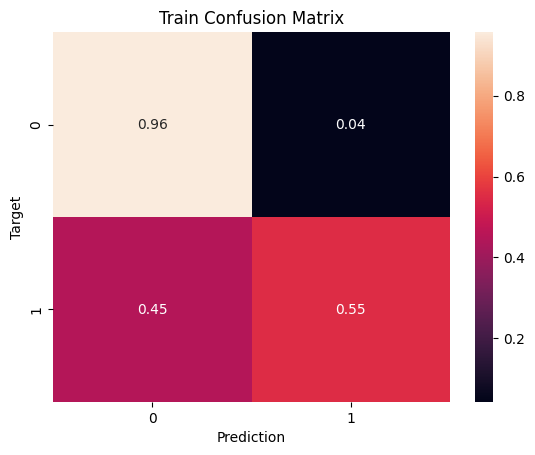

In [ ]:
train_preds = predict_and_plot(X_train, train_targets, 'Train')

Accuracy: 87.12%


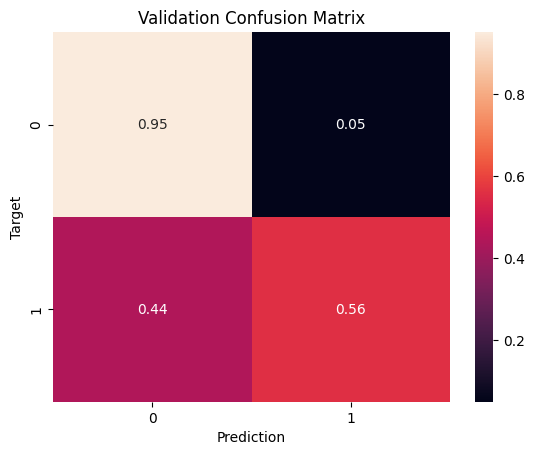

In [ ]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

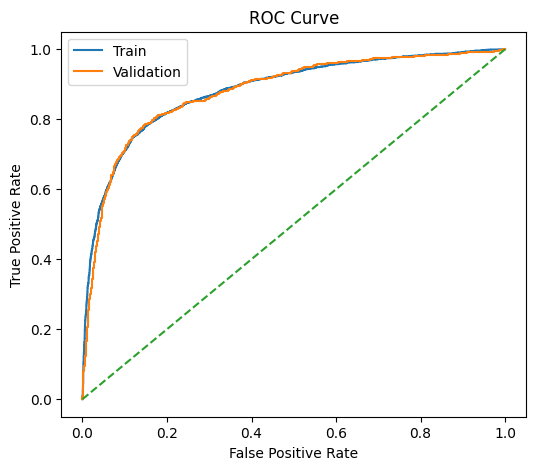

Train AUROC: 0.8827328013157741
Validation AUROC: 0.8799068571937549


In [ ]:
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_fpr, train_tpr, _ = roc_curve(y_train, train_probs)
val_fpr, val_tpr, _ = roc_curve(y_val, val_probs)

plt.figure(figsize=(6,5))
plt.plot(train_fpr, train_tpr, label='Train')
plt.plot(val_fpr, val_tpr, label='Validation')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print('Train AUROC:', roc_auc_score(y_train, train_probs))
print('Validation AUROC:', roc_auc_score(y_val, val_probs))

In [ ]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.64
F1 score Validation: 0.64


Побудована модель логістичної регресії показала схожі результати на тренувальній та валідаційній вибірках (Accuracy ≈ 85%, AUROC ≈ 0.88, F1-score ≈ 0.63–0.64). Це свідчить про те, що модель не має ознак перенавчання, оскільки її якість майже однакова на обох наборах даних.

Значення AUROC ≈ 0.88 означає, що модель добре відрізняє клієнтів, які покинуть банк, від тих, хто залишиться. F1-score ≈ 0.63 показує, що модель знаходить баланс між Precision і Recall, хоча ще допускає помилки при класифікації клієнтів, які залишають банк.

Загалом модель можна оцінити як хорошу. Вона стабільно працює як на тренувальних, так і на валідаційних даних, але її можна покращити за рахунок підбору гіперпараметрів або використання більш складних алгоритмів.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [ ]:
majority_class = y_train.mode()[0]

In [ ]:
train_majority_preds = np.full(len(y_train), majority_class)
val_majority_preds = np.full(len(y_val), majority_class)

# Accuracy baseline-моделі
train_majority_acc = accuracy_score(y_train, train_majority_preds)
val_majority_acc = accuracy_score(y_val, val_majority_preds)

# Accuracy логістичної регресії
train_model_acc = accuracy_score(y_train, model.predict(X_train))
val_model_acc = accuracy_score(y_val, model.predict(X_val))

print(f"Majority model train accuracy: {train_majority_acc:.4f}")
print(f"Majority model validation accuracy: {val_majority_acc:.4f}")

print(f"Logistic Regression train accuracy: {train_model_acc:.4f}")
print(f"Logistic Regression validation accuracy: {val_model_acc:.4f}")

Majority model train accuracy: 0.7965
Majority model validation accuracy: 0.7965
Logistic Regression train accuracy: 0.8749
Logistic Regression validation accuracy: 0.8712


Базова модель, яка завжди передбачає мажоритарний клас, досягла Accuracy 79.65% як на тренувальному, так і на валідаційному наборах. Натомість логістична регресія показала значно кращий результат: 87.46% на тренувальних даних та 87.09% на валідаційних. Це свідчить про те, що модель навчилася знаходити закономірності в даних, а не просто передбачати найпоширеніший клас. Оскільки точність на тренувальному та валідаційному наборах майже однакова, модель добре узагальнює дані й не демонструє явного перенавчання. Отже, якість моделі можна оцінити як хорошу.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [ ]:
log_reg = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [ ]:
joblib.dump(log_reg, 'drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/log_reg.joblib')

['drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/log_reg.joblib']

In [ ]:
model_2 = joblib.load('drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/log_reg.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [ ]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

array([0.00550933, 0.03365802, 0.37814366, 0.38116885, 0.97938757])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [ ]:
test_raw_df = pd.read_csv(
    'drive/MyDrive/Colab Notebooks/Machine Learning/bank-customer-churn-prediction-dlu-course-c-5/test.csv'
)

test_preds = predict_raw_df(
    scaler,
    encoder,
    numeric_cols,
    categorical_cols,
    test_raw_df.copy()
)

test_raw_df['Exited'] = test_preds

In [ ]:
display(test_raw_df.head())

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069077
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.032550
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.150992
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.200652
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.053413


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [ ]:
import opendatasets as od
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

Area under ROC score on Train dataset: 0.88%


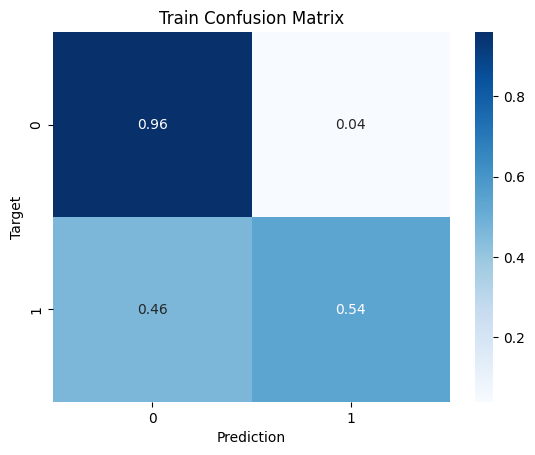

Area under ROC score on Validation dataset: 0.88%


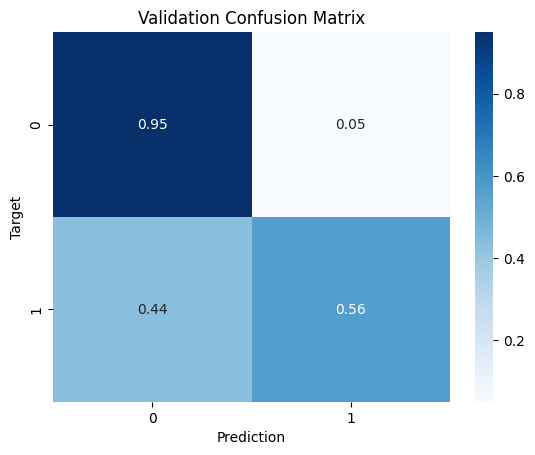

['bank_castomer_pipeline.joblib']

In [ ]:
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = train_df.columns.drop('Exited')
target_col = 'Exited'
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# Видаляжмо колонки, які вважаємо не потрібними
train_inputs = train_inputs.drop(columns=['CustomerId', 'Surname'])
val_inputs = val_inputs.drop(columns=['CustomerId', 'Surname'])

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.difference(['id']).tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline,train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'bank_castomer_pipeline.joblib')


Модель з поліноміальними ознаками (степінь 2)
Area under ROC score on Train dataset: 0.92%


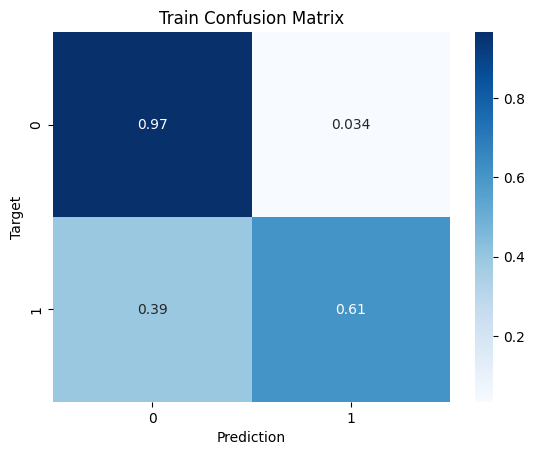

Area under ROC score on Validation dataset: 0.92%


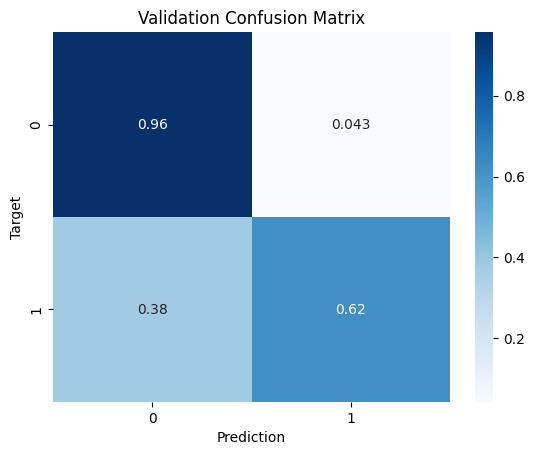

In [ ]:
# Створюємо НОВИЙ трансформер для числових колонок (додаємо поліноми)
numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# Створюємо НОВИЙ препроцесор
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Створюємо НОВИЙ загальний пайплайн
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо нову модель
model_pipeline_poly.fit(train_inputs, train_targets)

# Використовуємо функцію predict_and_plot для оцінки
print("Модель з поліноміальними ознаками (степінь 2)")
train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

Модель з поліноміальними ознаками (степінь 4)
Area under ROC score on Train dataset: 0.93%


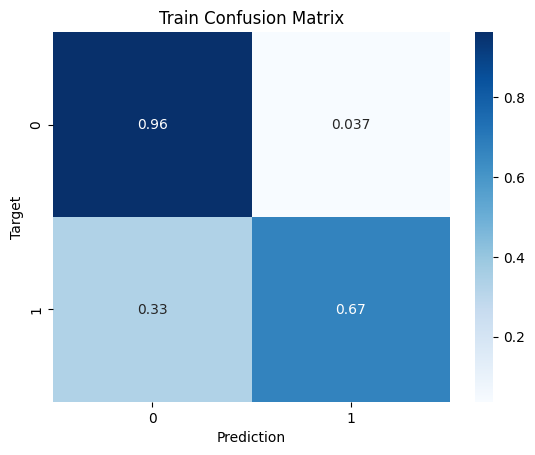

Area under ROC score on Validation dataset: 0.93%


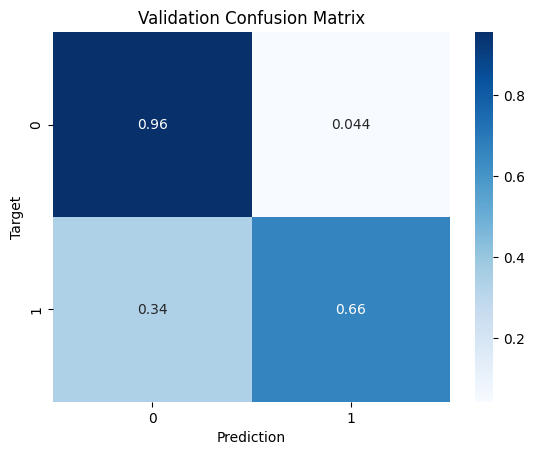

In [ ]:
# Створюємо трансформер для числових колонок зі степенем 4
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

# Створюємо новий препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Створюємо фінальний пайплайн
# Додаємо max_iter=1000, бо через велику кількість ознак моделі може знадобитись більше часу на навчання
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

# Тренуємо модель
model_pipeline_poly4.fit(train_inputs, train_targets)

# Оцінюємо результати
print("Модель з поліноміальними ознаками (степінь 4)")
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation')